# Maximum Likelihood Estimation (MLE) — Batch Quality Analysis

**Problem:** A food-processing laboratory records whether each tested batch meets a quality standard (Pass/Fail). Three candidate probability estimates are proposed. We implement MLE on the observed data, compute the likelihood for each candidate, and determine which candidate best represents the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import comb

df = pd.read_csv('../dataset/batch_quality_data.csv')
df.head(10)

,Batch_ID,Quality_Result,Result_Binary
0,B001,Pass,1
1,B002,Fail,0
2,B003,Fail,0
3,B004,Pass,1
4,B005,Pass,1
5,B006,Pass,1
6,B007,Pass,1
7,B008,Fail,0
8,B009,Pass,1
9,B010,Fail,0


## 1. Observed Data Summary

Each batch is modelled as an independent Bernoulli trial: 1 = Pass (meets standard), 0 = Fail.

In [2]:
n = len(df)
k = int(df['Result_Binary'].sum())
print(f'Total batches (n): {n}')
print(f'Batches meeting standard (k): {k}')
print(f'Batches failing standard: {n-k}')
print(f'Observed proportion (k/n): {k/n:.4f}')

Total batches (n): 40
Batches meeting standard (k): 29
Batches failing standard: 11
Observed proportion (k/n): 0.7250


## 2. Likelihood Function

For a Binomial process:

$$L(p) = \binom{n}{k} p^{k} (1-p)^{n-k}$$

$$\log L(p) = \log\binom{n}{k} + k\log(p) + (n-k)\log(1-p)$$

In [3]:
def likelihood(p, n, k):
    return comb(n, k) * (p**k) * ((1-p)**(n-k))

def log_likelihood(p, n, k):
    eps = 1e-12
    p = np.clip(p, eps, 1-eps)
    return np.log(comb(n, k)) + k*np.log(p) + (n-k)*np.log(1-p)

## 3. Candidate Probability Estimates

Three candidates proposed from the observed data are evaluated:
- Candidate A: p = 0.50 (naive guess)
- Candidate B: p = 0.60 (conservative estimate)
- Candidate C: p = k/n (sample proportion)

In [4]:
candidates = {
    'Candidate A (p=0.50)': 0.50,
    'Candidate B (p=0.60)': 0.60,
    'Candidate C (p=k/n)': k/n,
}

rows = []
for name, p in candidates.items():
    rows.append({'Candidate': name, 'p': p,
                  'Likelihood': likelihood(p, n, k),
                  'Log-Likelihood': log_likelihood(p, n, k)})

results_df = pd.DataFrame(rows)
results_df

,Candidate,p,Likelihood,Log-Likelihood
0,Candidate A (p=0.50),0.500,0.002103,-6.164594
1,Candidate B (p=0.60),0.600,0.035727,-3.331848
2,Candidate C (p=k/n),0.725,0.140092,-1.965458


## 4. Analytical MLE

For Bernoulli/Binomial data, the MLE has a closed form: $\hat{p}_{MLE} = k/n$.

In [5]:
p_mle = k/n
print(f'MLE estimate p_hat = {p_mle:.4f}')
print(f'Likelihood at MLE = {likelihood(p_mle, n, k):.6e}')
print(f'Log-Likelihood at MLE = {log_likelihood(p_mle, n, k):.4f}')

MLE estimate p_hat = 0.7250
Likelihood at MLE = 1.400917e-01
Log-Likelihood at MLE = -1.9655


## 5. Visualizing the Likelihood Function

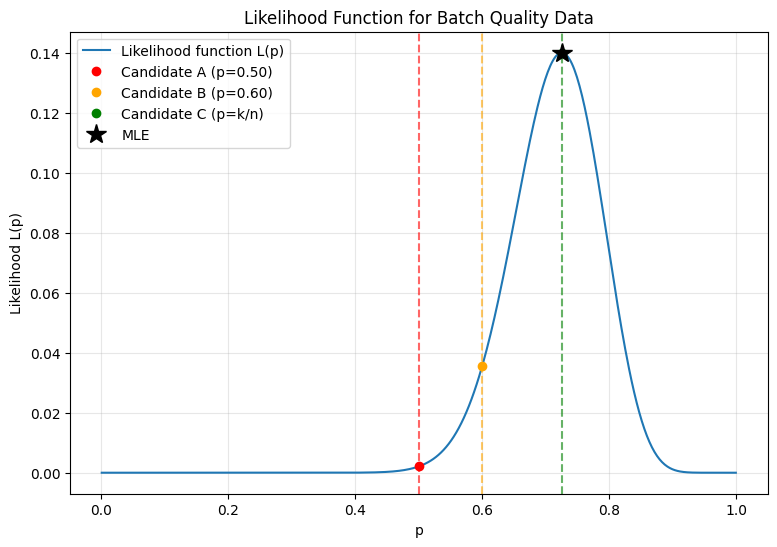

In [6]:
p_range = np.linspace(0.001, 0.999, 500)
L_values = likelihood(p_range, n, k)

plt.figure(figsize=(9,6))
plt.plot(p_range, L_values, label='Likelihood function L(p)')
colors = ['red', 'orange', 'green']
for (name, p), c in zip(candidates.items(), colors):
    plt.axvline(p, color=c, linestyle='--', alpha=0.6)
    plt.plot(p, likelihood(p, n, k), 'o', color=c, label=name)
plt.plot(p_mle, likelihood(p_mle, n, k), '*', color='black', markersize=15, label='MLE')
plt.xlabel('p')
plt.ylabel('Likelihood L(p)')
plt.title('Likelihood Function for Batch Quality Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()